In [1]:
import os
import torch, torchvision, time, copy, random, timm
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sn
import pandas as pd
from torch.cuda.amp import autocast, GradScaler
import time
import copy
import torch
import gc


RANDOM_SEED = 2

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

Num_class = 5

e:\Rodrigo Neves\dental-radiography-classification\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
import sys
print(sys.executable)
# !pwd
# %cd /content/drive/MyDrive/TCC/db-dental-radiography-classification/

e:\Rodrigo Neves\dental-radiography-classification\.venv\Scripts\python.exe


In [4]:
# Uncomment this if you are working with the zipped dataset
# with zipfile.ZipFile('/kaggle/input/dental-radiography-more-balanced-subset/Dental_Data.zip', 'r') as zip_ref:
#         # Extract all contents
#         zip_ref.extractall('./')

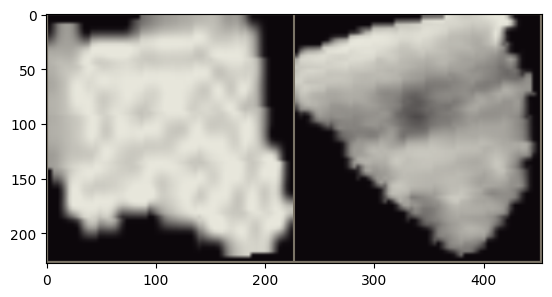

In [ ]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        #transforms.CenterCrop((470,470)),
        transforms.RandomRotation(10,),
        transforms.RandomPerspective(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomGrayscale(),
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276])
    ]),
    'test': transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276])
    ]),
}

data_dir = './'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'valid', 'test']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=2,
                                             shuffle=True, num_workers=0)
              for x in ['train', 'valid', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    plt.savefig('Augmented_data_train.pdf', bbox_inches = 'tight')
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out)#, title=[class_names[x] for x in classes])

In [6]:
# vit: Vision Transformer
model_ft = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=Num_class)

model_ft.set_grad_checkpointing(True)

#model_ft = models.wide_resnet101_2(pretrained=True)
#num_ftrs = model_ft.fc.in_features
#model_ft.fc = nn.Linear(num_ftrs, Num_class)

In [7]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, accumulation_steps=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    scaler = GradScaler()
    torch.backends.cudnn.benchmark = False 

    history = {
        'train_loss': [], 'train_acc': [],
        'valid_loss': [], 'valid_acc': []
    }

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            optimizer.zero_grad()

            for i, (inputs, labels) in enumerate(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast(enabled=(phase == 'train')):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    # Extraímos os números puros e somamos às estatísticas
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data).item()

                    # Treinamento e Acumulação
                    if phase == 'train':
                        scaled_loss = loss / accumulation_steps
                        scaler.scale(scaled_loss).backward()

                        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(dataloaders[phase]):
                            scaler.step(optimizer)
                            scaler.update()
                            optimizer.zero_grad()
                            
                            # Limpeza
                            del outputs, loss, scaled_loss, preds
                            gc.collect()
                            torch.cuda.empty_cache()
                    else:
                        del outputs, loss, preds
                        torch.cuda.empty_cache()

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # --- NOVO: Guardar os valores no histórico desta época ---
            history[f'{phase}_loss'].append(epoch_loss)
            
            # Convertendo tensor para float se necessário, para evitar problemas no plot
            if torch.is_tensor(epoch_acc):
                history[f'{phase}_acc'].append(epoch_acc.item())
            else:
                history[f'{phase}_acc'].append(epoch_acc)

            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    
    # Carrega os melhores pesos
    model.load_state_dict(best_model_wts)
    
    # Retorna o modelo treinado E o histórico de métricas
    return model, history

In [8]:
def plot_history(history):
    # Cria uma figura com dois gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfico 1: Loss (Perda)
    ax1.plot(history['train_loss'], label='Treino', marker='o')
    ax1.plot(history['valid_loss'], label='Validação', marker='o')
    ax1.set_title('Evolução do Cross-Entropy Loss')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Gráfico 2: Accuracy (Acurácia)
    ax2.plot(history['train_acc'], label='Treino', marker='o')
    ax2.plot(history['valid_acc'], label='Validação', marker='o')
    ax2.set_title('Evolução da Acurácia')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Acurácia')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Salva a imagem para usar no relatório/TCC
    fig.savefig('curvas_treinamento_baseline.png', dpi=300, bbox_inches='tight')
    print("✅ Gráfico salvo com sucesso como 'curvas_treinamento_baseline.png'")

Epoch 0/24
----------
train Loss: 0.8171 Acc: 0.6827
valid Loss: 0.6354 Acc: 0.7369

Epoch 1/24
----------
train Loss: 0.5200 Acc: 0.7977
valid Loss: 0.4669 Acc: 0.8238

Epoch 2/24
----------
train Loss: 0.4477 Acc: 0.8307
valid Loss: 0.4349 Acc: 0.8345

Epoch 3/24
----------
train Loss: 0.4039 Acc: 0.8522
valid Loss: 0.3849 Acc: 0.8583

Epoch 4/24
----------
train Loss: 0.3815 Acc: 0.8580
valid Loss: 0.3748 Acc: 0.8571

Epoch 5/24
----------
train Loss: 0.3367 Acc: 0.8740
valid Loss: 0.3987 Acc: 0.8571

Epoch 6/24
----------
train Loss: 0.3138 Acc: 0.8844
valid Loss: 0.4741 Acc: 0.8310

Epoch 7/24
----------
train Loss: 0.2477 Acc: 0.9045
valid Loss: 0.3327 Acc: 0.8833

Epoch 8/24
----------
train Loss: 0.2312 Acc: 0.9128
valid Loss: 0.3409 Acc: 0.8774

Epoch 9/24
----------
train Loss: 0.2231 Acc: 0.9141
valid Loss: 0.3273 Acc: 0.8750

Epoch 10/24
----------
train Loss: 0.2181 Acc: 0.9156
valid Loss: 0.3263 Acc: 0.8857

Epoch 11/24
----------
train Loss: 0.2185 Acc: 0.9175
valid Loss

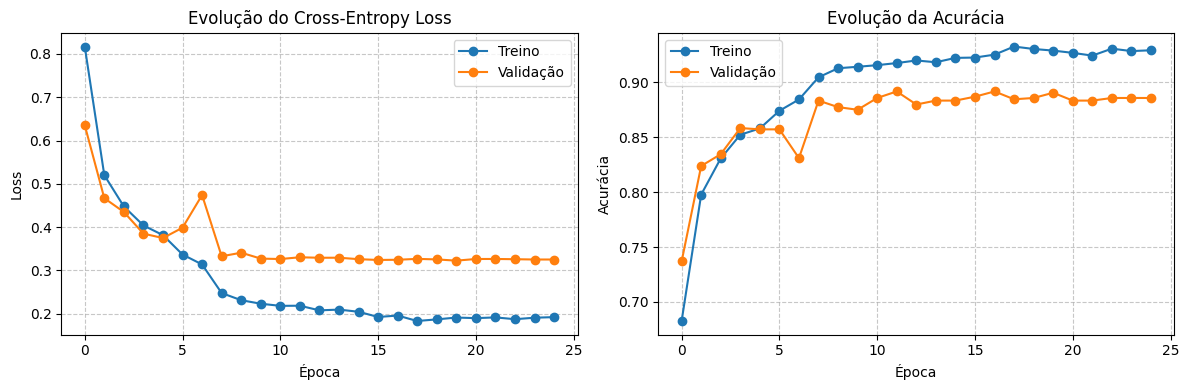

✅ Gráfico salvo com sucesso como 'curvas_treinamento_baseline.png'


In [9]:
model_ft = model_ft.to(device)
criterion = torch.nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = torch.optim.SGD(model_ft.parameters(), lr=0.0005, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# Resume from checkpoint if one exists
start_epoch = 0

torch.cuda.empty_cache()
model_ft, history = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=25)

plot_history(history)

In [10]:
y_pred = []
y_true = []
output_all =[]

# iterate over test data
for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        output = model_ft(inputs) # Feed Network
        #output = output[:,0:2]

        output = (torch.max(torch.exp(output), 1)[1]).data.cpu().numpy()
        y_pred.extend(output) # Save Prediction

        labels = labels.data.cpu().numpy()
        y_true.extend(labels) # Save Truth

Test Accuracy: 0.8641160949868074
Test F1 Score (macro): 0.7616567644498762
Test F1 Score (weighted): 0.8682933683397649


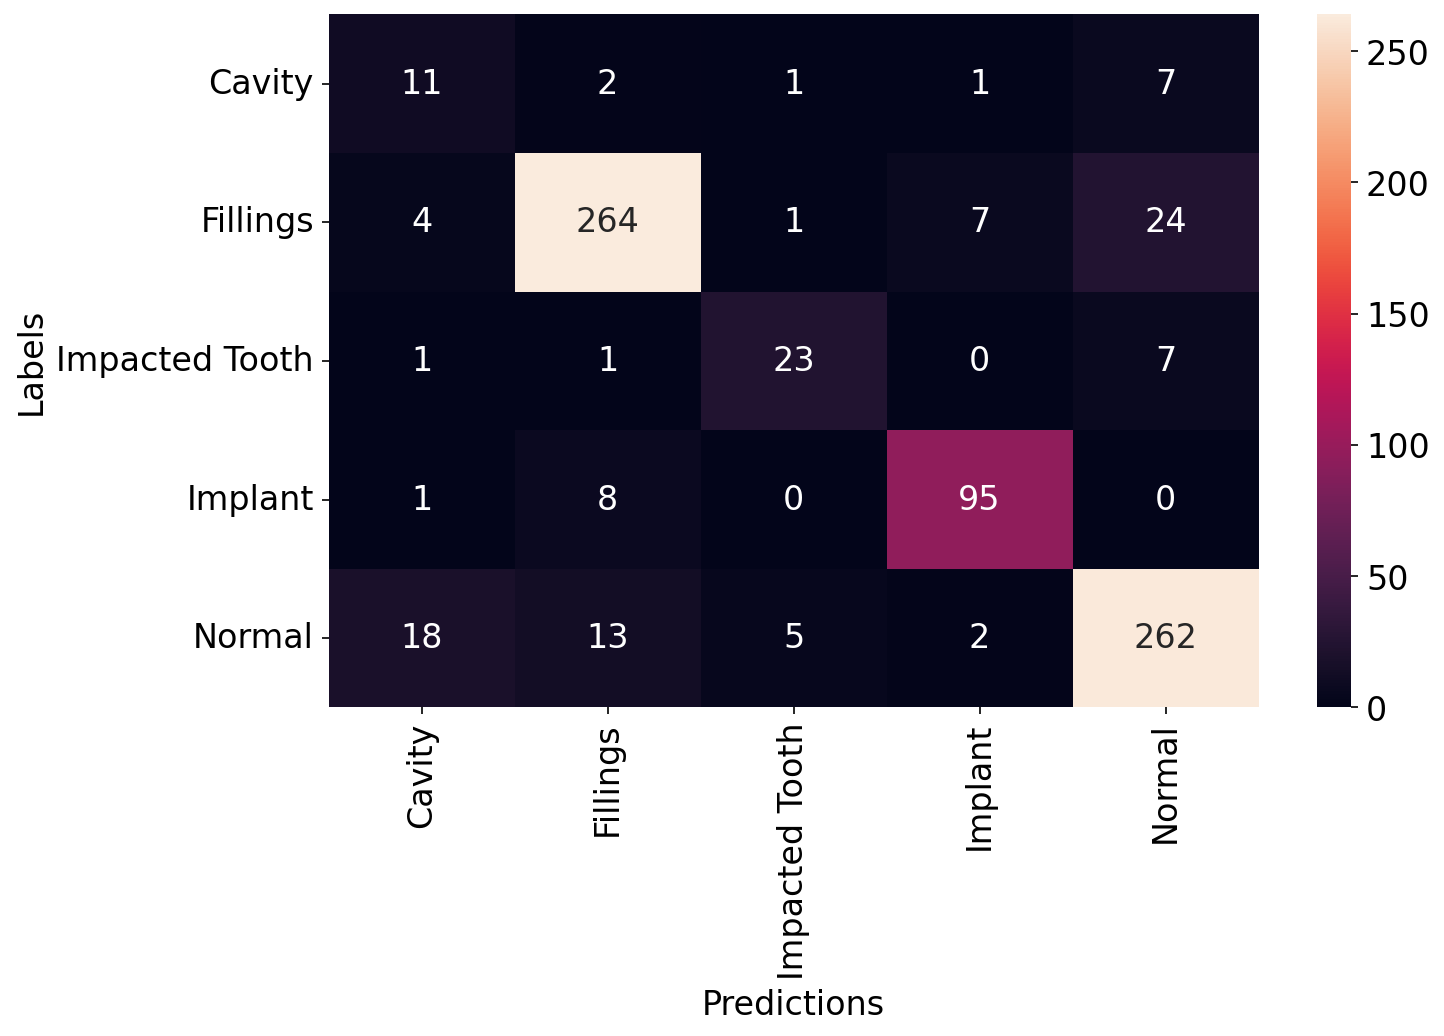

In [11]:
test_accuracy = 0
for iter1 in range(len(y_true)):
    if y_true[iter1] == y_pred[iter1]:
        test_accuracy = test_accuracy + 1

print('Test Accuracy:', test_accuracy / len(y_true))

# F1 scores computed only on test predictions
test_f1_macro = f1_score(y_true, y_pred, average='macro')
test_f1_weighted = f1_score(y_true, y_pred, average='weighted')
print('Test F1 Score (macro):', test_f1_macro)
print('Test F1 Score (weighted):', test_f1_weighted)

classes = ('Cavity','Fillings','Impacted Tooth','Implant','Normal')

# Build confusion matrix
cf_matrix = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])



plt.figure(figsize = (10,6),dpi=150)
plt.rcParams['font.size'] = '16'
fig = sn.heatmap(df_cm, annot=True, fmt=".0f")
plt.ylabel("Labels")
plt.xlabel("Predictions")
plt.show(fig)

fig.figure.savefig('Confusion_test.pdf', bbox_inches = 'tight')